In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
import optuna
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore', category=FutureWarning)

optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit, StratifiedKFold,
    StratifiedGroupKFold, cross_validate
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('../data/processed/combined_features.csv')
df.drop(columns=['duration', 'filename'], inplace=True)
df.dropna(inplace=True)

X = df.drop(columns='label')
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Full label distribution:")
print(y.value_counts())
print("\nTest set distribution:")
print(y_test.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

sampling_strategy = {
    'bronchitis': 300,
    'pneumonia': 300
}

smote = SMOTE(
    sampling_strategy=sampling_strategy,  
    k_neighbors=5,              
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)

print(pd.Series(y_train_resampled).value_counts())

Full label distribution:
label
healthy         1012
tuberculosis     840
covid            835
bronchitis        91
pneumonia         82
Name: count, dtype: int64

Test set distribution:
label
healthy         253
tuberculosis    210
covid           209
bronchitis       23
pneumonia        20
Name: count, dtype: int64
label
healthy         759
tuberculosis    630
covid           626
pneumonia       300
bronchitis      300
Name: count, dtype: int64


              precision    recall  f1-score   support

  bronchitis       0.68      0.57      0.62        23
       covid       0.62      0.60      0.61       209
     healthy       0.61      0.59      0.60       253
   pneumonia       0.58      0.70      0.64        20
tuberculosis       0.88      0.94      0.91       210

    accuracy                           0.70       715
   macro avg       0.68      0.68      0.68       715
weighted avg       0.69      0.70      0.70       715



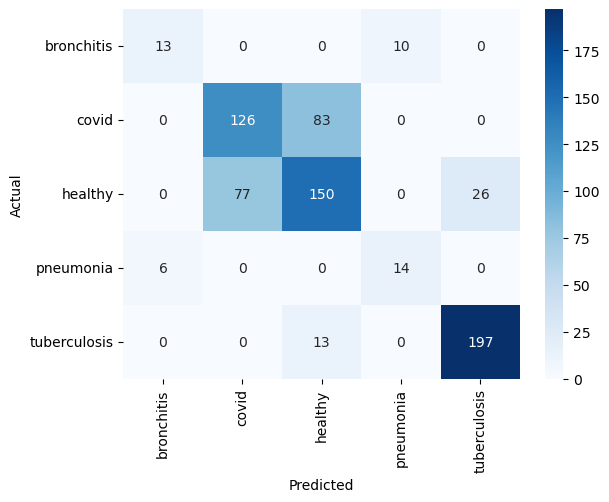

In [3]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_resampled, y_train_resampled)

logreg_predictions = logreg.predict(X_test_scaled)

print(classification_report(y_test, logreg_predictions))

cm_logreg = confusion_matrix(y_test, logreg_predictions, labels=logreg.classes_)
sns.heatmap(cm_logreg, annot=True, fmt='d', xticklabels=logreg.classes_, yticklabels=logreg.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

  bronchitis       0.76      0.70      0.73        23
       covid       0.55      0.76      0.64       209
     healthy       0.66      0.39      0.49       253
   pneumonia       0.68      0.75      0.71        20
tuberculosis       0.89      1.00      0.94       210

    accuracy                           0.70       715
   macro avg       0.71      0.72      0.70       715
weighted avg       0.70      0.70      0.68       715



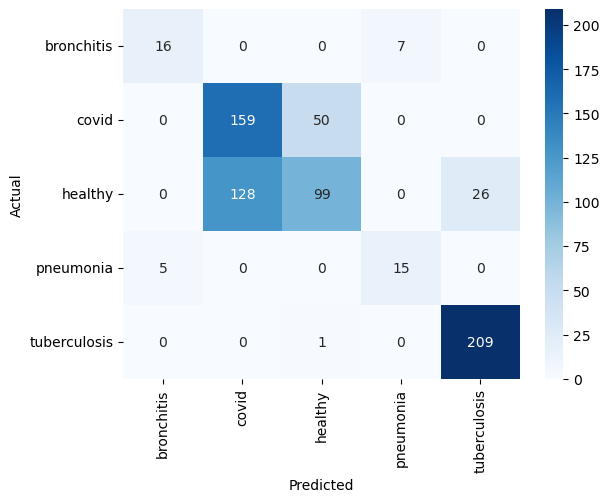

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf.predict(X_test_scaled)

print(classification_report(y_test, rf_predictions))

cm_rf = confusion_matrix(y_test, rf_predictions, labels=rf.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=rf.classes_, yticklabels=rf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

  bronchitis       0.80      0.70      0.74        23
       covid       0.54      0.56      0.55       209
     healthy       0.60      0.55      0.57       253
   pneumonia       0.68      0.75      0.71        20
tuberculosis       0.93      0.99      0.96       210

    accuracy                           0.69       715
   macro avg       0.71      0.71      0.71       715
weighted avg       0.69      0.69      0.69       715



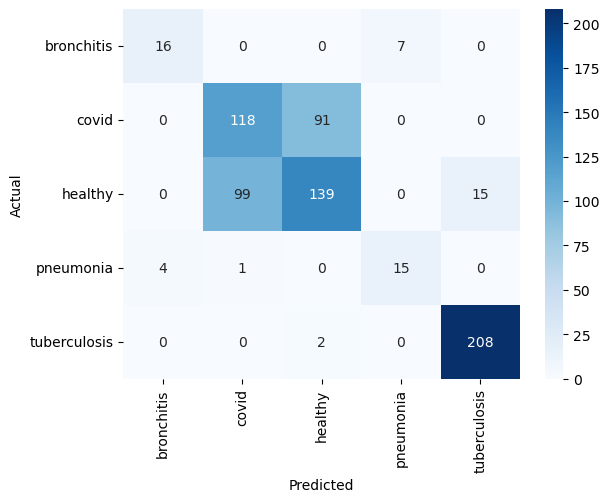

In [5]:
xgb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)

xgb_predictions = xgb.predict(X_test_scaled)

print(classification_report(y_test, xgb_predictions))

cm_xgb = confusion_matrix(y_test, xgb_predictions, labels=xgb.classes_)
sns.heatmap(cm_xgb, annot=True, fmt='d', xticklabels=xgb.classes_, yticklabels=xgb.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

  bronchitis       0.70      0.70      0.70        23
       covid       0.56      0.83      0.67       209
     healthy       0.74      0.40      0.52       253
   pneumonia       0.65      0.65      0.65        20
tuberculosis       0.93      1.00      0.96       210

    accuracy                           0.72       715
   macro avg       0.72      0.72      0.70       715
weighted avg       0.74      0.72      0.70       715



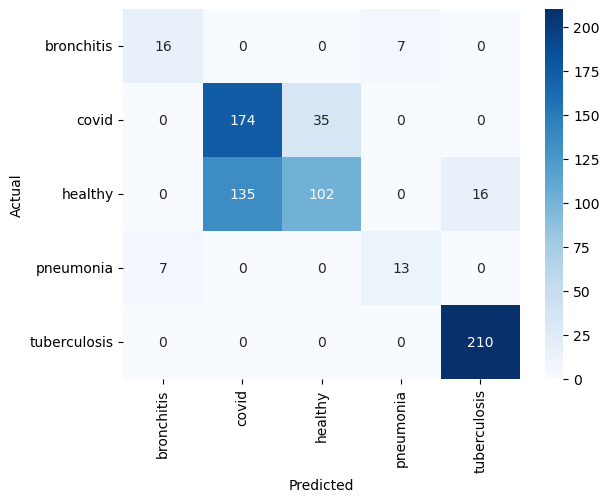

In [6]:
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train_resampled, y_train_resampled)

svm_predictions = svm.predict(X_test_scaled)

print(classification_report(y_test, svm_predictions))

cm_svm = confusion_matrix(y_test, svm_predictions, labels=svm.classes_)
sns.heatmap(cm_svm, annot=True, fmt='d', xticklabels=svm.classes_, yticklabels=svm.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

  bronchitis       0.68      0.65      0.67        23
       covid       0.57      0.60      0.58       209
     healthy       0.63      0.57      0.60       253
   pneumonia       0.62      0.65      0.63        20
tuberculosis       0.94      1.00      0.97       210

    accuracy                           0.71       715
   macro avg       0.69      0.69      0.69       715
weighted avg       0.71      0.71      0.71       715



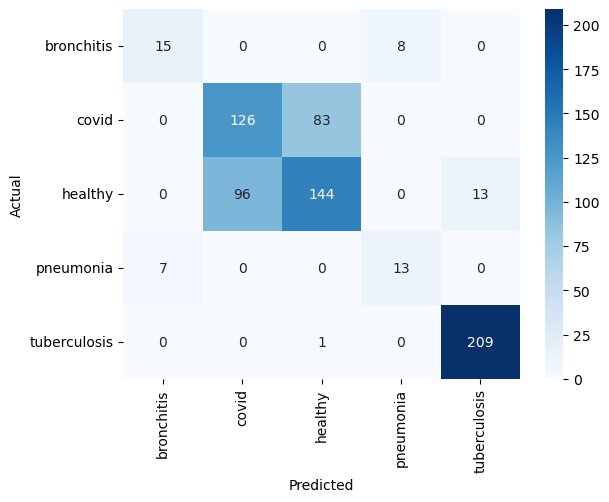

In [7]:
lgb = LGBMClassifier(n_estimators=300, num_leaves=15, min_child_samples=10, random_state=42, verbose=-1)
lgb.fit(X_train_resampled, y_train_resampled)

lgb_predictions = lgb.predict(X_test_scaled)

print(classification_report(y_test, lgb_predictions))

cm_lgb = confusion_matrix(y_test, lgb_predictions, labels=lgb.classes_)
sns.heatmap(cm_lgb, annot=True, fmt='d', xticklabels=lgb.classes_, yticklabels=lgb.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

  bronchitis       0.73      0.70      0.71        23
       covid       0.55      0.58      0.56       209
     healthy       0.61      0.54      0.58       253
   pneumonia       0.67      0.70      0.68        20
tuberculosis       0.93      1.00      0.96       210

    accuracy                           0.70       715
   macro avg       0.70      0.70      0.70       715
weighted avg       0.69      0.70      0.69       715



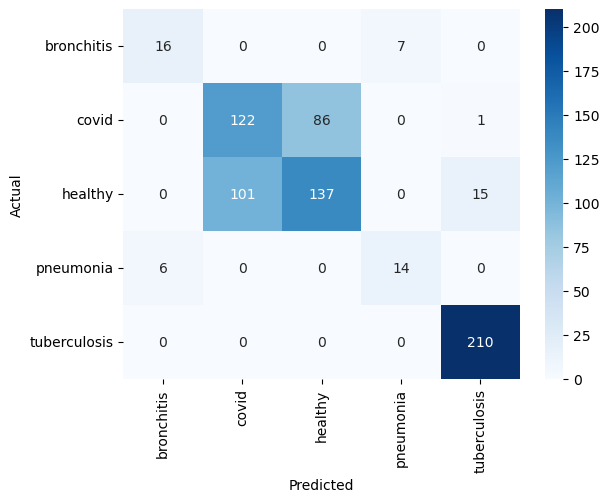

In [8]:
catboost = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, random_state=42, verbose=0)
catboost.fit(X_train_resampled, y_train_resampled)

catboost_predictions = catboost.predict(X_test_scaled)

print(classification_report(y_test, catboost_predictions))

cm_catboost = confusion_matrix(y_test, catboost_predictions, labels=catboost.classes_)
sns.heatmap(cm_catboost, annot=True, fmt='d', xticklabels=catboost.classes_, yticklabels=catboost.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
models = [
    ("Logistic Regression", logreg, logreg_predictions),
    ("Random Forest", rf, rf_predictions),
    ("Gradient Boosting", xgb, xgb_predictions),
    ("SVM", svm, svm_predictions),
    ("lgb", lgb, lgb_predictions),
    ("CatBoost", catboost, catboost_predictions),
]

for name, model, preds in models:
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    report = classification_report(y_test, preds)
    print(f'"{name}" : {cm},')
    print(report)

"Logistic Regression" : [[ 13   0   0  10   0]
 [  0 126  83   0   0]
 [  0  77 150   0  26]
 [  6   0   0  14   0]
 [  0   0  13   0 197]],
              precision    recall  f1-score   support

  bronchitis       0.68      0.57      0.62        23
       covid       0.62      0.60      0.61       209
     healthy       0.61      0.59      0.60       253
   pneumonia       0.58      0.70      0.64        20
tuberculosis       0.88      0.94      0.91       210

    accuracy                           0.70       715
   macro avg       0.68      0.68      0.68       715
weighted avg       0.69      0.70      0.70       715

"Random Forest" : [[ 16   0   0   7   0]
 [  0 159  50   0   0]
 [  0 128  99   0  26]
 [  5   0   0  15   0]
 [  0   0   1   0 209]],
              precision    recall  f1-score   support

  bronchitis       0.76      0.70      0.73        23
       covid       0.55      0.76      0.64       209
     healthy       0.66      0.39      0.49       253
   pneumonia      

              precision    recall  f1-score   support

  bronchitis       0.76      0.70      0.73        23
       covid       0.58      0.62      0.60       209
     healthy       0.64      0.56      0.60       253
   pneumonia       0.68      0.75      0.71        20
tuberculosis       0.93      1.00      0.97       210

    accuracy                           0.72       715
   macro avg       0.72      0.73      0.72       715
weighted avg       0.71      0.72      0.71       715



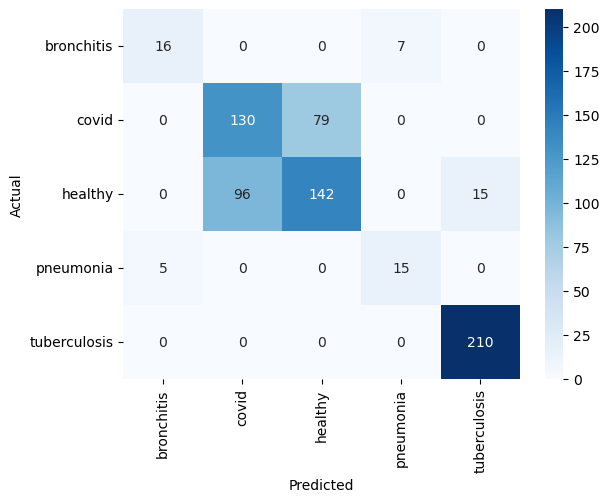

In [10]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)),
    ('catboost', CatBoostClassifier(iterations=300, random_state=42, verbose=0))
], voting='soft')

voting.fit(X_train_resampled, y_train_resampled)
voting_predictions = voting.predict(X_test_scaled)

print(classification_report(y_test, voting_predictions))

cm_voting = confusion_matrix(y_test, voting_predictions, labels=voting.classes_)
sns.heatmap(cm_voting, annot=True, fmt='d', xticklabels=voting.classes_, yticklabels=voting.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


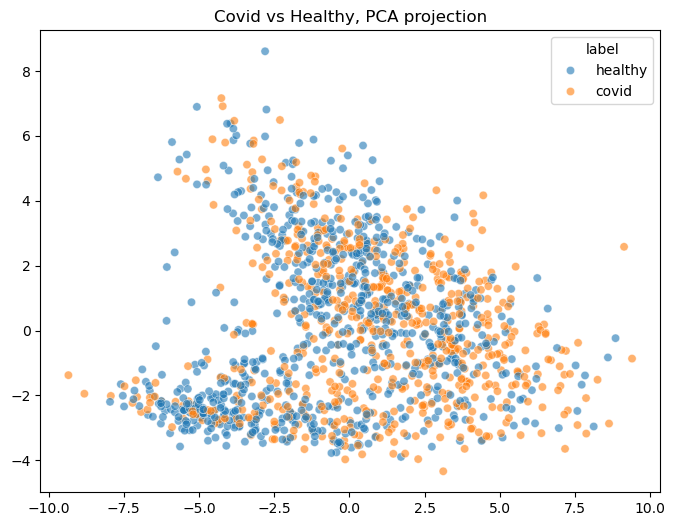

In [11]:
mask = y.isin(['covid', 'healthy'])
X_binary = X[mask]
y_binary = y[mask]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_binary, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

scaler_b = StandardScaler()
Xb_train_scaled = scaler_b.fit_transform(Xb_train)
Xb_test_scaled = scaler_b.transform(Xb_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xb_train_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=yb_train, alpha=0.6)
plt.title('Covid vs Healthy, PCA projection')
plt.show()

In [19]:
def objective1(trial):
    gb = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('gb_n_estimators', 100, 400),
        max_depth=trial.suggest_int('gb_max_depth', 3, 8),
        learning_rate=trial.suggest_float('gb_lr', 0.01, 0.3, log=True),
        random_state=42
    )
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int('rf_n_estimators', 100, 400),
        max_depth=trial.suggest_int('rf_max_depth', 4, 15),
        class_weight='balanced',
        random_state=42
    )
    svm = SVC(
        C=trial.suggest_float('svm_c', 0.1, 10, log=True),
        gamma=trial.suggest_float('svm_gamma', 0.001, 1, log=True),
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    )
    catboost = CatBoostClassifier(
        iterations=trial.suggest_int('cb_iterations', 100, 400),
        depth=trial.suggest_int('cb_depth', 4, 8),
        random_state=42, verbose=0
    )

    ensemble = VotingClassifier(estimators=[('gb', gb), ('rf', rf), ('svm', svm), ('catboost', catboost)], voting='soft')

    scores = cross_val_score(ensemble, X_train_resampled, y_train_resampled, cv=5, scoring='f1_macro')
    return scores.mean()

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline

def objective(trial):
    gb = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('gb_n_estimators', 100, 400),
        max_depth=trial.suggest_int('gb_max_depth', 3, 8),
        learning_rate=trial.suggest_float('gb_lr', 0.01, 0.3, log=True),
        random_state=42
    )
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int('rf_n_estimators', 100, 400),
        max_depth=trial.suggest_int('rf_max_depth', 4, 15),
        class_weight='balanced', random_state=42
    )
    svm = SVC(
        C=trial.suggest_float('svm_c', 0.1, 10, log=True),
        gamma=trial.suggest_float('svm_gamma', 0.001, 1, log=True),
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    )
    catboost = CatBoostClassifier(
        iterations=trial.suggest_int('cb_iterations', 100, 400),
        depth=trial.suggest_int('cb_depth', 4, 8),
        random_state=42, verbose=0
    )

    ensemble = VotingClassifier(estimators=[('gb', gb), ('rf', rf), ('svm', svm), ('catboost', catboost)], voting='soft')

    # SMOTE now happens INSIDE each fold, only on that fold's training portion
    pipeline = ImbPipeline([
        ('smote', SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=42)),
        ('ensemble', ensemble)
    ])

    scores = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

In [21]:
study = optuna.create_study(direction='maximize', study_name='respiratory_voting_ensemble_tuning')
study.optimize(objective, n_trials=17, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best macro F1:", study.best_value)

  0%|          | 0/17 [00:00<?, ?it/s]

Best parameters: {'gb_n_estimators': 330, 'gb_max_depth': 5, 'gb_lr': 0.08521363241220987, 'rf_n_estimators': 198, 'rf_max_depth': 4, 'svm_c': 8.853832586449576, 'svm_gamma': 0.002519641738010949, 'cb_iterations': 331, 'cb_depth': 8}
Best macro F1: 0.6825129283625347


In [13]:
study = optuna.create_study(direction='maximize', study_name='respiratory_voting_ensemble_tuning')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best macro F1:", study.best_value)

  0%|          | 0/30 [00:00<?, ?it/s]

Best parameters: {'gb_n_estimators': 374, 'gb_max_depth': 7, 'gb_lr': 0.028368879287697855, 'rf_n_estimators': 331, 'rf_max_depth': 14, 'svm_c': 5.343320829351655, 'svm_gamma': 0.29138247019627017, 'cb_iterations': 332, 'cb_depth': 8}
Best macro F1: 0.8197760736665748


              precision    recall  f1-score   support

  bronchitis       0.76      0.70      0.73        23
       covid       0.58      0.60      0.59       209
     healthy       0.64      0.58      0.61       253
   pneumonia       0.68      0.75      0.71        20
tuberculosis       0.94      1.00      0.97       210

    accuracy                           0.72       715
   macro avg       0.72      0.72      0.72       715
weighted avg       0.71      0.72      0.71       715



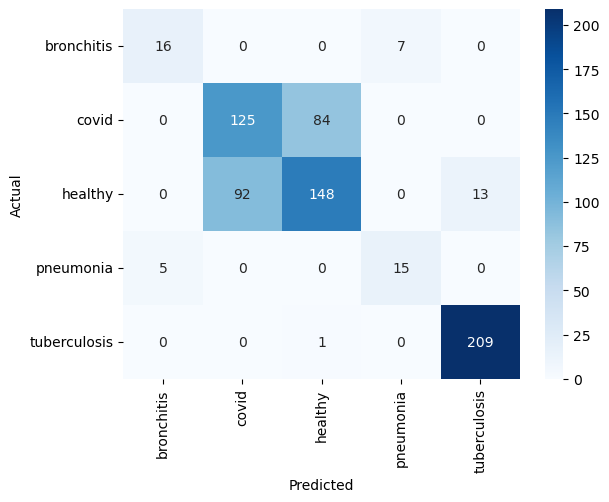

In [15]:
best_params = study.best_params

final_model = VotingClassifier(estimators=[
    ('gb', GradientBoostingClassifier(
        n_estimators=best_params['gb_n_estimators'],
        max_depth=best_params['gb_max_depth'],
        learning_rate=best_params['gb_lr'],
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=best_params['rf_n_estimators'],
        max_depth=best_params['rf_max_depth'],
        class_weight='balanced',
        random_state=42
    )),
    ('svm', SVC(
        C=best_params['svm_c'],
        gamma=best_params['svm_gamma'],
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    )),
    ('catboost', CatBoostClassifier(
        iterations=best_params['cb_iterations'],
        depth=best_params['cb_depth'],
        random_state=42, verbose=0
    ))
], voting='soft')

final_model.fit(X_train_resampled, y_train_resampled)

final_predictions = final_model.predict(X_test_scaled)
print(classification_report(y_test, final_predictions, zero_division=0))

cm_final = confusion_matrix(y_test, final_predictions, labels=final_model.classes_)
sns.heatmap(cm_final, annot=True, fmt='d', xticklabels=final_model.classes_, yticklabels=final_model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()